# 4 - Compressed sensing with a generative prior


> Part of **[Compressed Sensing using Generative Models](../README.md)**.
> Run `pip install -e .` from the repository root first; every notebook imports
> the `csgm` package rather than redefining the model and recovery code inline.


This is the core experiment. We observe only $m \ll n$ noisy linear
measurements of an unknown digit,

$$y = A x^* + \eta, \qquad A \in \mathbb{R}^{m \times n},\; \eta \sim \mathcal{N}(0, \sigma^2 I),$$

and reconstruct $x^*$ by searching the **range of a trained generator** instead
of the set of sparse vectors:

$$\hat z = \arg\min_z \; \|A G(z) - y\|_2^2 + \lambda \|z\|_2^2, \qquad \hat x = G(\hat z).$$

The objective is non-convex - $G$ is a deep network - so it is minimised with
Adam from several random initialisations, keeping the restart with the smallest
residual. Bora et al. (2017) show that if $G$ is $L$-Lipschitz, roughly
$O(k \log L)$ measurements suffice for an $\ell_2/\ell_2$ recovery guarantee: the
cost scales with the **latent** dimension, not the ambient one.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from csgm.baselines import lasso_dct_recover
from csgm.config import DEFAULT_SEED, N_PIXELS
from csgm.data import load_mnist
from csgm.measurements import gaussian_measurement_matrix, measure
from csgm.metrics import per_pixel_l2, psnr
from csgm.models import load_generator
from csgm.recovery import RecoveryConfig, recover
from csgm.viz import plot_error_curves, show_images

## 4.1 A generator and a target

target digit: 7


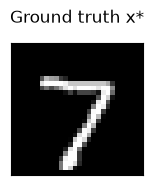

In [2]:
latent_dim = 20
G = load_generator("dcgan", latent_dim)     # or load_generator("vae", 20)

(_, _), (x_test, y_test) = load_mnist(flatten=True)
x_star = x_test[0]
print("target digit:", y_test[0])

show_images(np.stack([x_star]), ncols=1, suptitle="Ground truth x*");

## 4.2 One reconstruction, step by step

With $m = 100$ we keep 13% of the pixels' worth of information. Note that $z$ is
initialised from $\mathcal{N}(0, I)$ - the same prior the generator was trained
under. Starting much closer to the origin biases the search towards the blurry
centre of the latent space and measurably hurts the result.

In [3]:
m = 100
A = gaussian_measurement_matrix(m, N_PIXELS, seed=DEFAULT_SEED)
y = measure(x_star, A, noise_std=0.1 / np.sqrt(m), seed=DEFAULT_SEED)
print("y has", y.shape[1], "numbers describing a", N_PIXELS, "pixel image")

result = recover(
    G, y, A, latent_dim,
    RecoveryConfig(steps=1000, restarts=10, learning_rate=0.01, log_every=200),
    track_history=True,
)
print(f"per-pixel error {per_pixel_l2(result.x_hat, x_star)[0]:.4f}"
      f" | PSNR {psnr(result.x_hat, x_star)[0]:.2f} dB")

y has 100 numbers describing a 784 pixel image


  step     0 | mean objective 87.63528


  step   200 | mean objective 42.84965


  step   400 | mean objective 30.68534


  step   600 | mean objective 28.45849


  step   800 | mean objective 26.71822


per-pixel error 0.0049 | PSNR 23.10 dB


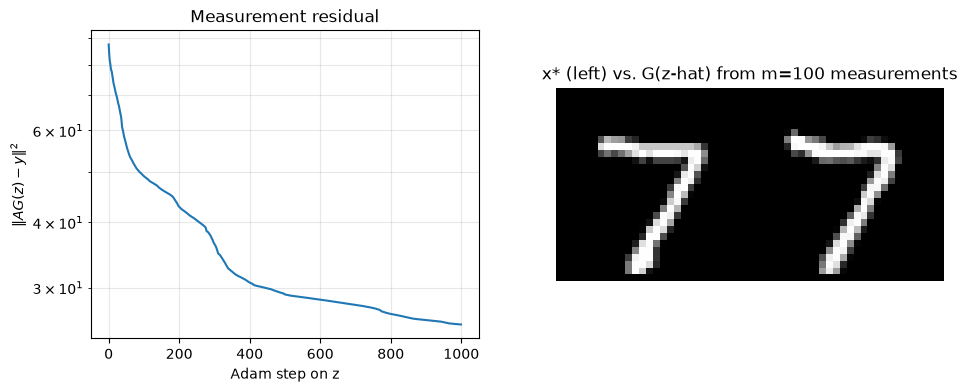

In [4]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))
left.plot(result.history)
left.set_yscale("log")
left.set_xlabel("Adam step on z")
left.set_ylabel(r"$\|A G(z) - y\|^2$")
left.set_title("Measurement residual")
left.grid(alpha=0.3, which="both")

right.imshow(
    np.concatenate([x_star.reshape(28, 28), result.x_hat[0].reshape(28, 28)], axis=1),
    cmap="gray", vmin=0, vmax=1,
)
right.set_title(f"x* (left) vs. G(z-hat) from m={m} measurements")
right.axis("off");

The residual falls by orders of magnitude and then flattens: what remains is the
**representation error**, the distance between $x^*$ and the closest point in
the range of $G$. No amount of extra optimisation removes it - only a better
generator does. This is the term that sets the error floor in the next section.

## 4.3 Why random restarts matter

The objective is non-convex, so different initialisations land in different
local minima. The spread below is the reason the recovery loop keeps the best of
ten rather than trusting a single run.

best/worst residual ratio: 0.59645385


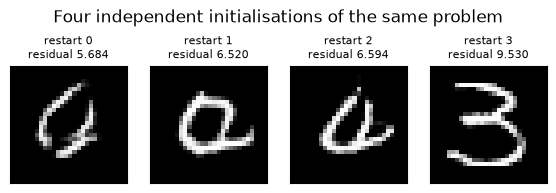

In [5]:
residuals, images = [], []
for seed in range(4):
    single = recover(G, y, A, latent_dim, RecoveryConfig(steps=1000, restarts=1, seed=seed))
    residuals.append(single.residual[0])
    images.append(single.x_hat[0])

show_images(
    np.stack(images),
    [f"restart {i}\nresidual {r:.3f}" for i, r in enumerate(residuals)],
    ncols=4,
    suptitle="Four independent initialisations of the same problem",
)
print("best/worst residual ratio:", min(residuals) / max(residuals))

## 4.4 Sweeping the measurement budget

Now the comparison the whole project is about: the same images, the same
measurement matrices, four learned priors and the sparse baseline, across ten
measurement budgets.

Running that sweep here would take hours, so it lives in a script that writes
its results to disk:

```bash
python scripts/run_benchmark.py --n-images 10 --steps 1000 --restarts 10
```

This section reads what that run produced. Every number below therefore comes
from the same seeded, reproducible experiment as the figures in the README.

In [6]:
import pandas as pd

from csgm.config import RESULTS_DIR

benchmark = pd.read_csv(RESULTS_DIR / "benchmark.csv")
print(f"{benchmark['image'].nunique()} images x {benchmark['m'].nunique()} budgets "
      f"x {benchmark['method'].nunique()} methods = {len(benchmark)} reconstructions")

mean_error = benchmark.pivot_table(index="m", columns="method", values="per_pixel_error")
mean_error

10 images x 10 budgets x 5 methods = 500 reconstructions


method,dcgan-20,dcgan-30,lasso,vae-20,vae-30
m,,,,,
10,0.104794,0.079766,0.153948,0.069628,0.078196
25,0.062325,0.048705,0.104883,0.040080,0.024984
50,0.042593,0.032128,0.084972,0.032836,0.015315
75,0.024512,0.031486,0.070670,0.033634,0.011109
100,0.014364,0.027028,0.056003,0.028718,0.015825
200,0.010479,0.020954,0.036623,0.031941,0.007145
300,0.010916,0.021932,0.020569,0.026847,0.006733
400,0.009899,0.019584,0.011681,0.031096,0.006717
500,0.009327,0.020852,0.006543,0.026660,0.006795


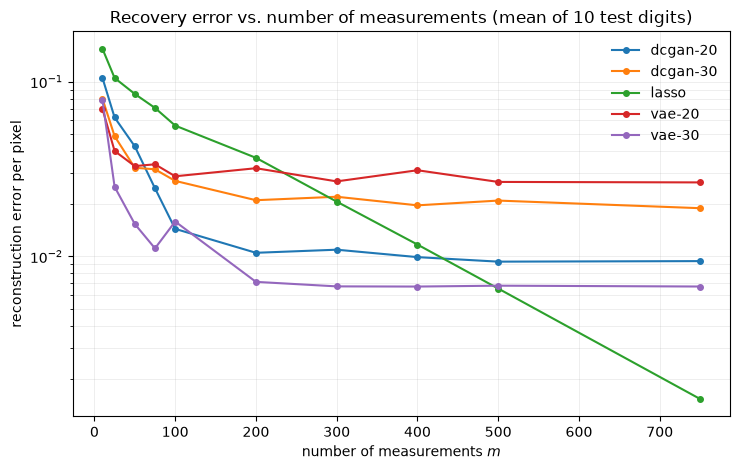

In [7]:
plot_error_curves(
    {method: (column.index, column.to_numpy()) for method, column in mean_error.items()},
    title="Recovery error vs. number of measurements (mean of 10 test digits)",
);

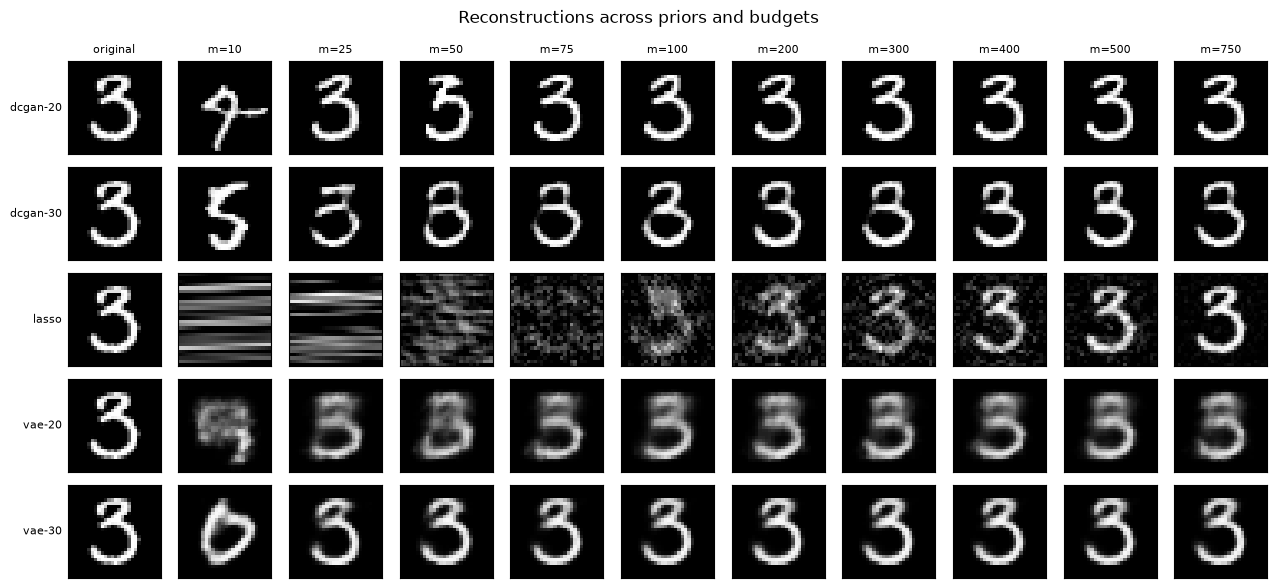

In [8]:
with np.load(RESULTS_DIR / "reconstructions.npz") as archive:
    recons = dict(archive)

methods = list(mean_error.columns)
m_values = sorted(benchmark["m"].unique())
digit = 0

fig, axes = plt.subplots(len(methods), len(m_values) + 1, figsize=(1.05 * len(m_values) + 2.4, 1.05 * len(methods) + 0.7))
for row, method in enumerate(methods):
    axes[row][0].imshow(recons["ground_truth"][digit].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
    axes[row][0].set_ylabel(method, fontsize=8, rotation=0, ha="right", va="center")
    if row == 0:
        axes[row][0].set_title("original", fontsize=8)
    for col, m in enumerate(m_values, start=1):
        axes[row][col].imshow(recons[f"{method}__m{m}"][digit].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
        if row == 0:
            axes[row][col].set_title(f"m={m}", fontsize=8)
for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Reconstructions across priors and budgets")
fig.tight_layout();

## 4.5 What the curves say

**The learned priors win where measurements are scarce.** At $m = 25$ the VAE
with $k = 30$ reaches a per-pixel error of 0.0250 against 0.1049 for Lasso, 4.2
times lower, at a budget where the Lasso reconstruction is not a digit at all.
Put the other way round: Lasso needs 400 measurements to reach 0.0117, and the
VAE with $k = 30$ gets there with 75. That is a **5.3x** saving, at the bottom
of the 5 to 10x range Bora et al. report.

**They also stop improving.** Past roughly 200 measurements the generative
curves go flat, at 0.0068 for the VAE $k=30$, 0.0100 for the DCGAN $k=20$,
0.0204 for the DCGAN $k=30$ and 0.0286 for the VAE $k=20$. That floor is the
representation error: the distance from a real digit to the range of $G$, which
no measurement budget and no amount of optimisation can remove. Lasso has no
such ceiling, so it overtakes every learned prior from $m = 500$ and is 4.4
times more accurate at $m = 750$. The reference paper predicts exactly this
reversal and places it past 500 measurements.

**The VAE beats the DCGAN here.** The VAE with $k = 30$ is the most accurate of
the five methods at seven of the ten budgets, while being about 38 times cheaper
to invert. The DCGAN produces visibly sharper digits, which is what adversarial
training optimises for, but a sharp digit of the wrong shape scores worse than a
slightly blurred one of the right shape.

**The latent dimension behaves differently in the two families.** For the VAE,
$k = 30$ is better from $m = 50$ upwards by 2.6 to 4.7 standard errors, so the
difference is real. For the DCGAN, $k = 20$ is ahead from $m = 75$ and the sign
is consistent, but the gap never exceeds 1.9 standard errors over ten images, so
it is a trend rather than a result.

The practical reading: a learned prior is the right choice exactly when
measurements are the scarce resource, which is the situation compressed sensing
exists for. It is the wrong choice when measurements are cheap and
reconstructions are frequent.

---
See [`results/`](../results) for the full table and
[the report](../docs/NAML_project_report.pdf) for the write-up.